In [ ]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Координаты городов берем относительные для упрощения
# еще одно допущение - все маршруты - по прямой и расстояния туда-обратно равны
cities = {
    "Москва": (0.0, 0.0), # Центр координат и стартовая/конечная точка
    "Ярославль": (1.5, 2.5),
    "Кострома": (2.2, 2.8),
    "Иваново": (2.0, 1.8),
    "Владимир": (1.2, 0.8),
    "Рязань": (0.5, -0.8),
    "Тула": (-0.8, -0.5),
    "Калуга": (-1.2, 0.3),
    "Нижний Новгород": (3, 1)
}
city_names = list(cities.keys())
city_coords = torch.tensor([cities[name] for name in city_names], dtype=torch.float32)
n_cities = len(city_names)

In [ ]:
# 2. Функция для вычисления матрицы расстояний
def compute_distance_matrix(coords):
    diff = coords.unsqueeze(1) - coords.unsqueeze(0)
    dist_matrix = torch.sqrt((diff ** 2).sum(dim=2))
    return dist_matrix

dist_matrix = compute_distance_matrix(city_coords)
dist_matrix # это еще называется платежной матрицей. Эта матрица симметрична

tensor([[0.0000, 2.9155, 3.5609, 2.6907, 1.4422, 0.9434, 0.9434, 1.2369, 3.1623],
        [2.9155, 0.0000, 0.7616, 0.8602, 1.7263, 3.4482, 3.7802, 3.4828, 2.1213],
        [3.5609, 0.7616, 0.0000, 1.0198, 2.2361, 3.9812, 4.4598, 4.2202, 1.9698],
        [2.6907, 0.8602, 1.0198, 0.0000, 1.2806, 3.0017, 3.6235, 3.5341, 1.2806],
        [1.4422, 1.7263, 2.2361, 1.2806, 0.0000, 1.7464, 2.3854, 2.4515, 1.8111],
        [0.9434, 3.4482, 3.9812, 3.0017, 1.7464, 0.0000, 1.3342, 2.0248, 3.0806],
        [0.9434, 3.7802, 4.4598, 3.6235, 2.3854, 1.3342, 0.0000, 0.8944, 4.0853],
        [1.2369, 3.4828, 4.2202, 3.5341, 2.4515, 2.0248, 0.8944, 0.0000, 4.2579],
        [3.1623, 2.1213, 1.9698, 1.2806, 1.8111, 3.0806, 4.0853, 4.2579, 0.0000]])

In [ ]:
# 3. Создаем обучаемые параметры (логиты) — матрица вероятностей переходов
logits = torch.randn(n_cities, n_cities, requires_grad=True)

# Запрещаем оставаться в том же городе (диагональ)
with torch.no_grad():
    logits.fill_diagonal_(-float('Inf'))

# Оптимизатор
optimizer = optim.Adam([logits], lr=0.01)

Как управлять вариативностью выбора???

temperature (температура) — это параметр, который контролирует, насколько "уверенной" или "случайной" будет модель при выборе следующего города. t>1 - Модель исследует больше вариантов, даже плохих; t<1 - модель тяготеет к уже найденным лучшим вариантам не стараясь искать другие (как в холодной комнате — все жмутся к источнику тепла (лучшему варианту))

In [ ]:
# 4. Функция потерь (упрощенная)
def compute_loss(logits, dist_matrix, temperature=1):
    # Превращаем логиты в вероятности (с температурой)
    probs = torch.softmax(logits / temperature, dim=1)

    # Потеря = средневзвешенная длина маршрута
    # (чем меньше потеря, тем лучше)
    loss = (probs * dist_matrix).sum()

    return loss, probs

Softmax здесь выполняет ключевую функцию: превращает дискретные числа (очередность посещения городов) в вероятности, которые можно дифференцировать и оптимизировать.

In [ ]:
# 5. Функция для получения конкретного маршрута (для отображения)
def get_greedy_tour(probs):
    n = probs.shape[0]
    visited = [False] * n
    tour = [0]  # начинаем с Москвы (индекс 0)
    visited[0] = True
    current = 0

    for _ in range(n - 1):
        # Маскируем посещенные города
        masked_probs = probs[current].clone()
        masked_probs[visited] = -float('inf')
        next_city = torch.argmax(masked_probs).item()
        tour.append(next_city)
        visited[next_city] = True
        current = next_city

    # Замыкаем маршрут (возвращаемся в начало)
    tour.append(tour[0])
    return tour

In [ ]:
# 6. Обучающий цикл
for epoch in range(1000):
    optimizer.zero_grad()
    loss, probs = compute_loss(logits, dist_matrix, temperature=1)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"{epoch:5d} | {loss.item():.4f}")

    0 | 22.7558
   20 | 21.1105
   40 | 19.5071
   60 | 18.0209
   80 | 16.7269
  100 | 15.6351
  120 | 14.7111
  140 | 13.9102
  160 | 13.2002
  180 | 12.5669
  200 | 12.0126
  220 | 11.5420
  240 | 11.1481
  260 | 10.8146
  280 | 10.5244
  300 | 10.2665
  320 | 10.0376
  340 | 9.8398
  360 | 9.6741
  380 | 9.5373
  400 | 9.4243
  420 | 9.3300
  440 | 9.2507
  460 | 9.1836
  480 | 9.1266
  500 | 9.0779
  520 | 9.0363
  540 | 9.0003
  560 | 8.9692
  580 | 8.9420
  600 | 8.9181
  620 | 8.8971
  640 | 8.8783
  660 | 8.8616
  680 | 8.8466
  700 | 8.8330
  720 | 8.8208
  740 | 8.8096
  760 | 8.7994
  780 | 8.7901
  800 | 8.7816
  820 | 8.7737
  840 | 8.7664
  860 | 8.7597
  880 | 8.7534
  900 | 8.7476
  920 | 8.7422
  940 | 8.7371
  960 | 8.7324
  980 | 8.7279


In [ ]:
# 7. Финальный результат
final_probs = torch.softmax(logits, dim=1)
final_tour = get_greedy_tour(final_probs)

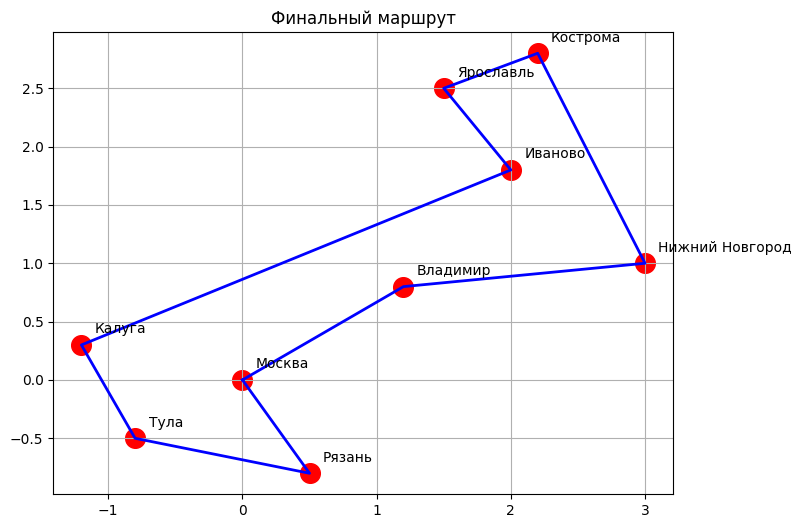


Маршрут: Москва → Рязань → Тула → Калуга → Иваново → Ярославль → Кострома → Нижний Новгород → Владимир → Москва


In [ ]:
# Визуализация финального маршрута
plt.figure(figsize=(8, 6))
coords_np = city_coords.numpy()

# Рисуем города
plt.scatter(coords_np[:, 0], coords_np[:, 1], c='red', s=200)
for i, name in enumerate(city_names):
    plt.annotate(name, (coords_np[i, 0] + 0.1, coords_np[i, 1] + 0.1))

# Рисуем маршрут
route_coords = coords_np[final_tour]
plt.plot(route_coords[:, 0], route_coords[:, 1], 'b-', linewidth=2)
plt.title("Финальный маршрут")
plt.grid(True)
plt.show()

print(f"\nМаршрут: {' → '.join([city_names[i] for i in final_tour])}")

Попробуйте самостоятельно поуправлять параметрами оптимизации и сравните результаты

1. Выбор лучшего маршрута методом перебора

In [ ]:
best_loss = float('inf')
best_tour = None
n_trials = 50

for trial in range(n_trials):
    # Новая случайная инициализация
    logits = torch.randn(n_cities, n_cities, requires_grad=True)
    with torch.no_grad():
        logits.fill_diagonal_(-float('Inf'))

    optimizer = optim.Adam([logits], lr=0.01)

    # Обучение
    for epoch in range(200):
        optimizer.zero_grad()
        loss, probs = compute_loss(logits, dist_matrix, temperature=0.5)
        loss.backward()
        optimizer.step()

    # Сохраняем лучший результат
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_probs = torch.softmax(logits, dim=1)
        best_tour = get_greedy_tour(best_probs)
        print(f"Новый лучший результат: {best_loss:.4f}")

print(f"\nЛучший маршрут (потеря={best_loss:.4f}):")
print(' → '.join([city_names[i] for i in best_tour]))

Новый лучший результат: 9.3769
Новый лучший результат: 9.2500

Лучший маршрут (потеря=9.2500):
Москва → Тула → Калуга → Рязань → Иваново → Ярославль → Кострома → Владимир → Нижний Новгород → Москва


2. Изменять температуру по расписанию (отжиг)

In [ ]:
def train_with_annealing(initial_temp=2.0, final_temp=0.1, epochs=300):
    logits = torch.randn(n_cities, n_cities, requires_grad=True)
    with torch.no_grad():
        logits.fill_diagonal_(-float('Inf'))

    optimizer = optim.Adam([logits], lr=0.01)
    temperatures = np.linspace(initial_temp, final_temp, epochs)

    for epoch, temp in enumerate(temperatures):
        optimizer.zero_grad()
        loss, probs = compute_loss(logits, dist_matrix, temperature=temp)
        loss.backward()
        optimizer.step()

    final_probs = torch.softmax(logits, dim=1)
    return get_greedy_tour(final_probs), loss.item()

# Пробуем с разными начальными температурами
for temp in [2.0, 1.5, 1.0, 0.5]:
    tour, loss = train_with_annealing(initial_temp=temp)
    print(f"temp={temp}: потеря={loss:.4f}")

temp=2.0: потеря=9.2495
temp=1.5: потеря=9.2700
temp=1.0: потеря=9.0119
temp=0.5: потеря=8.6225


А если применить регуляризацию и шедулинг?

Преимущества комбинации:
В начале: высокая энтропия + высокий LR → исследование пространства

В середине: постепенное снижение обоих параметров

В конце: низкая энтропия + низкий LR → точная настройка


Обучение с энтропией и scheduler'ом (300 эпох)
Эпоха   0 | loss=21.3048 | temp=2.000 | entropy=1.965 | ent_weight=0.300 | lr=0.05000
Эпоха  50 | loss=12.9062 | temp=1.700 | entropy=1.472 | ent_weight=0.252 | lr=0.04652
Эпоха 100 | loss=9.7533 | temp=1.400 | entropy=0.844 | ent_weight=0.203 | lr=0.03727
Эпоха 150 | loss=8.9117 | temp=1.100 | entropy=0.488 | ent_weight=0.155 | lr=0.02474
Эпоха 200 | loss=8.6795 | temp=0.800 | entropy=0.245 | ent_weight=0.107 | lr=0.01227
Эпоха 250 | loss=8.6289 | temp=0.500 | entropy=0.096 | ent_weight=0.058 | lr=0.00322
Финальный маршрут (длина = 13.66):
Москва → Рязань → Тула → Калуга → Владимир → Иваново → Ярославль → Кострома → Нижний Новгород → Москва


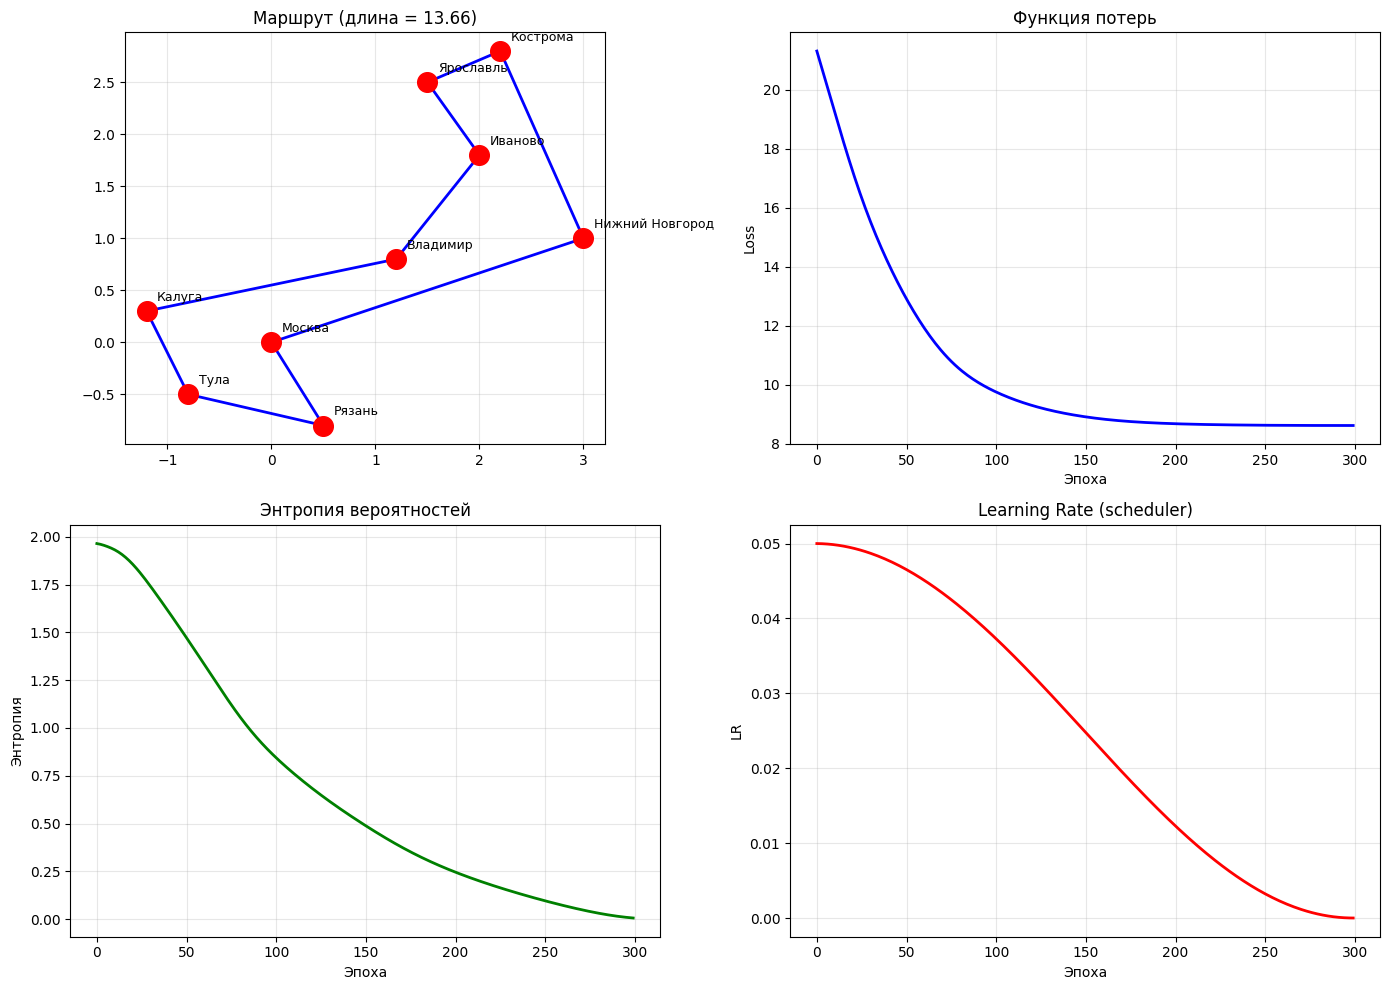

СРАВНЕНИЕ С ОБЫЧНЫМ ОБУЧЕНИЕМ

Запуск 1/10

Обучение с энтропией и scheduler'ом (200 эпох)
Эпоха   0 | loss=22.1266 | temp=2.000 | entropy=1.968 | ent_weight=0.300 | lr=0.05000
Эпоха  50 | loss=13.0148 | temp=1.550 | entropy=1.434 | ent_weight=0.227 | lr=0.04240
Эпоха 100 | loss=9.7088 | temp=1.100 | entropy=0.634 | ent_weight=0.155 | lr=0.02461
Эпоха 150 | loss=8.8641 | temp=0.650 | entropy=0.177 | ent_weight=0.082 | lr=0.00705
  Обычное: 13.52 | Продвинутое: 13.92

Запуск 2/10

Обучение с энтропией и scheduler'ом (200 эпох)
Эпоха   0 | loss=20.7478 | temp=2.000 | entropy=1.979 | ent_weight=0.300 | lr=0.05000
Эпоха  50 | loss=12.5619 | temp=1.550 | entropy=1.437 | ent_weight=0.227 | lr=0.04240
Эпоха 100 | loss=9.4777 | temp=1.100 | entropy=0.693 | ent_weight=0.155 | lr=0.02461
Эпоха 150 | loss=8.8548 | temp=0.650 | entropy=0.344 | ent_weight=0.082 | lr=0.00705
  Обычное: 13.64 | Продвинутое: 13.64

Запуск 3/10

Обучение с энтропией и scheduler'ом (200 эпох)
Эпоха   0 | loss=21.4590 | 

/tmp/ipykernel_2867/1407901299.py:242: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([basic_lengths, advanced_lengths],


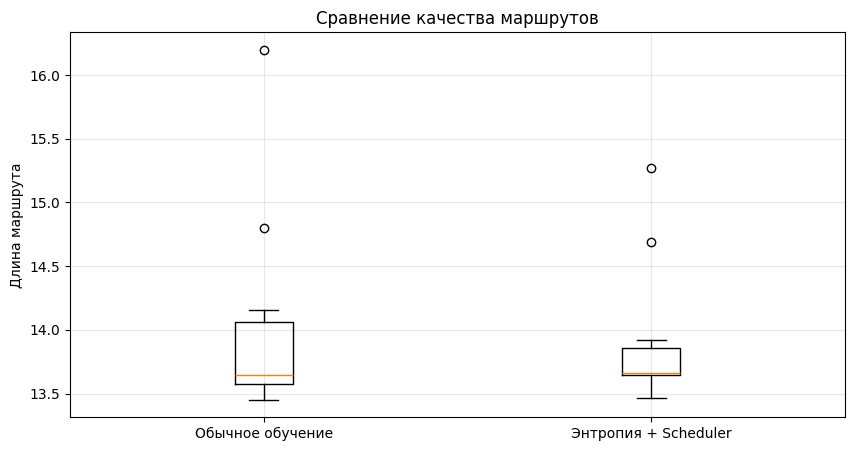

In [ ]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Данные городов
cities = {
    "Москва": (0.0, 0.0),
    "Ярославль": (1.5, 2.5),
    "Кострома": (2.2, 2.8),
    "Иваново": (2.0, 1.8),
    "Владимир": (1.2, 0.8),
    "Рязань": (0.5, -0.8),
    "Тула": (-0.8, -0.5),
    "Калуга": (-1.2, 0.3),
    "Нижний Новгород": (3, 1)
}
city_names = list(cities.keys())
city_coords = torch.tensor([cities[name] for name in city_names], dtype=torch.float32)
n_cities = len(city_names)

# Матрица расстояний
def compute_distance_matrix(coords):
    diff = coords.unsqueeze(1) - coords.unsqueeze(0)
    dist_matrix = torch.sqrt((diff ** 2).sum(dim=2))
    return dist_matrix

dist_matrix = compute_distance_matrix(city_coords)

# Функция для получения маршрута
def get_greedy_tour(probs):
    n = probs.shape[0]
    visited = [False] * n
    tour = [0]
    visited[0] = True
    current = 0

    for _ in range(n - 1):
        masked_probs = probs[current].clone()
        masked_probs[visited] = -float('inf')
        next_city = torch.argmax(masked_probs).item()
        tour.append(next_city)
        visited[next_city] = True
        current = next_city

    tour.append(tour[0])
    return tour

# Функция для вычисления реальной длины маршрута
def calculate_tour_length(tour, dist_matrix):
    length = 0
    for i in range(len(tour) - 1):
        length += dist_matrix[tour[i], tour[i+1]].item()
    return length

# Энтропия + Scheduler

def train_with_entropy_and_scheduler(epochs=300,
                                     lr=0.05,
                                     entropy_start=0.3,
                                     entropy_end=0.01,
                                     temp_start=2.0,
                                     temp_end=0.2):
    """
    регуляризация энтропией
    оптимизатор с расписанием (scheduler)
    """

    # Инициализация параметров
    logits = torch.randn(n_cities, n_cities, requires_grad=True)
    with torch.no_grad():
        logits.fill_diagonal_(-float('Inf'))

    # Оптимизатор Adam с расписанием learning rate
    optimizer = optim.Adam([logits], lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # Управление расписанием работы градиентного спуска

    # Для записи истории
    loss_history = []
    entropy_history = []
    lr_history = []

    print(f"\nОбучение с энтропией и scheduler'ом ({epochs} эпох)")

    for epoch in range(epochs):
        # Динамические параметры
        progress = epoch / epochs

        # Температура уменьшается
        temperature = temp_start * (1 - progress) + temp_end * progress

        # Энтропия заставляет модель пробовать разные варианты (энтропия показывает насколько трудно предсказать исход случайного эксперимента):
        # Вес энтропии уменьшается
        entropy_weight = entropy_start * (1 - progress) + entropy_end * progress

        # Прямой проход
        probs = torch.softmax(logits / temperature, dim=1)

        # Потеря: длина маршрута - энтропия * вес
        weighted_dist = (probs * dist_matrix).sum()
        entropy = - (probs * torch.log(probs + 1e-10)).sum() / n_cities
        loss = weighted_dist - entropy_weight * entropy

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Сохраняем историю
        loss_history.append(loss.item())
        entropy_history.append(entropy.item())
        lr_history.append(optimizer.param_groups[0]['lr'])

        # Выводим прогресс
        if epoch % 50 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Эпоха {epoch:3d} | loss={loss.item():.4f} | "
                  f"temp={temperature:.3f} | entropy={entropy.item():.3f} | "
                  f"ent_weight={entropy_weight:.3f} | lr={current_lr:.5f}")

    # Финальный маршрут
    final_probs = torch.softmax(logits, dim=1)
    final_tour = get_greedy_tour(final_probs)
    final_length = calculate_tour_length(final_tour, dist_matrix)

    return final_tour, final_length, loss_history, entropy_history, lr_history


tour, length, loss_hist, entropy_hist, lr_hist = train_with_entropy_and_scheduler(
    epochs=300,
    lr=0.05,
    entropy_start=0.3,   # сильная энтропия в начале
    entropy_end=0.01,     # слабая энтропия в конце
    temp_start=2.0,       # высокая температура в начале
    temp_end=0.2          # низкая температура в конце
)

# Вывод результатов
print(f"Финальный маршрут (длина = {length:.2f}):")
print(' → '.join([city_names[i] for i in tour]))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Маршрут на карте
ax1 = axes[0, 0]
coords_np = city_coords.numpy()
ax1.scatter(coords_np[:, 0], coords_np[:, 1], c='red', s=200, zorder=5)
for i, name in enumerate(city_names):
    ax1.annotate(name, (coords_np[i, 0] + 0.1, coords_np[i, 1] + 0.1), fontsize=9)
route_coords = coords_np[tour]
ax1.plot(route_coords[:, 0], route_coords[:, 1], 'b-', linewidth=2)
ax1.set_title(f"Маршрут (длина = {length:.2f})")
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# 2. График потери
ax2 = axes[0, 1]
ax2.plot(loss_hist, 'b-', linewidth=2)
ax2.set_title("Функция потерь")
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)

# 3. График энтропии
ax3 = axes[1, 0]
ax3.plot(entropy_hist, 'g-', linewidth=2)
ax3.set_title("Энтропия вероятностей")
ax3.set_xlabel("Эпоха")
ax3.set_ylabel("Энтропия")
ax3.grid(True, alpha=0.3)

# 4. График learning rate
ax4 = axes[1, 1]
ax4.plot(lr_hist, 'r-', linewidth=2)
ax4.set_title("Learning Rate (scheduler)")
ax4.set_xlabel("Эпоха")
ax4.set_ylabel("LR")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("СРАВНЕНИЕ С ОБЫЧНЫМ ОБУЧЕНИЕМ")

# Обычное обучение (без энтропии и scheduler'а)
def train_basic(epochs=300):
    logits = torch.randn(n_cities, n_cities, requires_grad=True)
    with torch.no_grad():
        logits.fill_diagonal_(-float('Inf'))

    optimizer = optim.Adam([logits], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss, probs = compute_loss(logits, dist_matrix, temperature=0.5)
        loss.backward()
        optimizer.step()

    final_probs = torch.softmax(logits, dim=1)
    tour = get_greedy_tour(final_probs)
    return calculate_tour_length(tour, dist_matrix)

# Запускаем несколько раз для статистики
n_runs = 10
basic_lengths = []
advanced_lengths = []

for i in range(n_runs):
    print(f"\nЗапуск {i+1}/{n_runs}")

    # Обычное обучение
    basic_len = train_basic()
    basic_lengths.append(basic_len)

    # Продвинутое обучение (наш метод)
    _, adv_len, _, _, _ = train_with_entropy_and_scheduler(
        epochs=200,  # меньше эпох для скорости
        #verbose=False
    )
    advanced_lengths.append(adv_len)

    print(f"  Обычное: {basic_len:.2f} | Продвинутое: {adv_len:.2f}")

# Статистика
print(f"Обычное обучение:")
print(f"  Среднее: {np.mean(basic_lengths):.2f}")
print(f"  Мин: {np.min(basic_lengths):.2f}")
print(f"  Макс: {np.max(basic_lengths):.2f}")
print(f"  Стд. отклонение: {np.std(basic_lengths):.2f}")

print(f"\nПродвинутое обучение (энтропия + scheduler):")
print(f"  Среднее: {np.mean(advanced_lengths):.2f}")
print(f"  Мин: {np.min(advanced_lengths):.2f}")
print(f"  Макс: {np.max(advanced_lengths):.2f}")
print(f"  Стд. отклонение: {np.std(advanced_lengths):.2f}")

# Визуализация сравнения
plt.figure(figsize=(10, 5))
plt.boxplot([basic_lengths, advanced_lengths],
            labels=['Обычное обучение', 'Энтропия + Scheduler'])
plt.title('Сравнение качества маршрутов')
plt.ylabel('Длина маршрута')
plt.grid(True, alpha=0.3)
plt.show()